In [65]:
import os
import pandas as pd
from PIL import Image
import numpy as np

csv_file = 'train.csv'
image_dir = 'train_images'
resized_image_dir = 'new_resized'

# Ensure the resized directory exists
if not os.path.exists(resized_image_dir):
    os.makedirs(resized_image_dir)

# Function to preprocess and save an image
def preprocess_and_save_image(image_path, output_path):
    image = Image.open(image_path)
    image = image.resize((128, 128), Image.LANCZOS)  
    image.save(output_path)
    return np.array(image)

# Load the data
data = pd.read_csv(csv_file)

# Add the image paths
data['image_path'] = data['id_code'].apply(lambda x: os.path.join(image_dir, f"{x}.png"))

# Preprocess and save images
X = []
for image_id, image_path, diagnosis in zip(data['id_code'], data['image_path'], data['diagnosis']):
    output_filename = f"{image_id}_{diagnosis}.png"
    output_path = os.path.join(resized_image_dir, output_filename)
    
    # Preprocess and save the image
    resized_image = preprocess_and_save_image(image_path, output_path)
    X.append(resized_image)

print("Images resized, renamed with diagnosis, and preprocessing complete!")


Images resized, renamed with diagnosis, and preprocessing complete!


In [79]:
import cv2
import os
import pandas as pd

# Directories
resized_image_dir = 'new_resized'
gaussian_image_dir = 'gaussian_blur'

if not os.path.exists(gaussian_image_dir):
    os.makedirs(gaussian_image_dir)

csv_file = 'train.csv'
data = pd.read_csv(csv_file)

for i in range(len(data)):
    image_id = data.loc[i, 'id_code']
    diagnosis = data.loc[i, 'diagnosis']

    image_filename = f"{image_id}_{diagnosis}.png"
    image_path = os.path.join(resized_image_dir, image_filename)

    # Read and process the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error loading image: {image_path}")
        continue  

    # Apply Gaussian blur enhancement
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), 128 / 40), -4, 128)  

    gaussian_image_filename = f"{image_id}_{diagnosis}.png"
    gaussian_image_path = os.path.join(gaussian_image_dir, gaussian_image_filename)
    cv2.imwrite(gaussian_image_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR)) 

print("Gaussian blur processing and saving complete!")


Gaussian blur processing and saving complete!


In [6]:
import os
import random
import shutil

# Directories
gaussian_image_dir = 'gaussian_blur'
validation_dir = 'validation'

if not os.path.exists(validation_dir):
    os.makedirs(validation_dir)

all_images = os.listdir(gaussian_image_dir)

# Randomly select 1000 images
selected_images = random.sample(all_images, 1000)

# Move images
for image_name in selected_images:
    source_path = os.path.join(gaussian_image_dir, image_name)
    destination_path = os.path.join(validation_dir, image_name)
    shutil.move(source_path, destination_path)

print(f"Randomly selected 1000 images and moved to '{validation_dir}' folder.")


Randomly selected 1000 images and moved to 'validation' folder.


In [9]:
import os
import pandas as pd

# Directories
validation_dir = 'validation'
csv_file_path = 'validation.csv'

validation_data = []

for image_name in os.listdir(validation_dir):
    try:

        id_code = f"{image_name}.png" if not image_name.endswith('.png') else image_name
        diagnosis = int(image_name.split('_')[-1].split('.')[0])
        validation_data.append({'id_code': id_code, 'diagnosis': diagnosis})
    except ValueError:
        print(f"Skipping improperly formatted file: {image_name}")
        continue

validation_df = pd.DataFrame(validation_data)

validation_df.to_csv(csv_file_path, index=False)

print(f"Validation CSV file created and saved as '{csv_file_path}'.")


Validation CSV file created and saved as 'validation.csv'.


In [35]:
import os
import pandas as pd

# Directories
gaussian_image_dir = 'gaussian_blur'
csv_file_path = 'gaussian_blur.csv'

gaussian_data = []

for image_name in os.listdir(gaussian_image_dir):
    try:
        image_id, diagnosis = image_name.rsplit('_', 1)
        diagnosis = diagnosis.split('.')[0]  
        gaussian_data.append({'id_code': image_id, 'diagnosis': int(diagnosis)})
    except ValueError:
        print(f"Skipping improperly formatted file: {image_name}")
        continue

# Convert the list to a DataFrame
gaussian_df = pd.DataFrame(gaussian_data)

gaussian_df.to_csv(csv_file_path, index=False)

print(f"Gaussian blur CSV file created and saved as '{csv_file_path}'.")


Gaussian blur CSV file created and saved as 'gaussian_blur.csv'.


In [25]:
import os
import shutil
import random
import pandas as pd

source_dir = 'gaussian_blur'  
test_dir = 'gauss_testing' 

csv_file = 'gaussian_blur.csv'  
df = pd.read_csv(csv_file)


category_mapping = {
    0: 'no_dr',
    1: 'mild',
    2: 'moderate',
    3: 'severe',
    4: 'proliferate_dr'
}

if not os.path.exists(test_dir):
    os.makedirs(test_dir)

for diagnosis, category in category_mapping.items():
    test_category_path = os.path.join(test_dir, category)

    if not os.path.exists(test_category_path):
        os.makedirs(test_category_path)
    
    images_in_category = df[df['diagnosis'] == diagnosis]['id_code'].tolist()
    
    # Select 10 images 
    test_images = random.sample(images_in_category, 10)
    
    # Move image to directory
    for img_id in test_images:
        img_filename = f"{img_id}.png"
        src_img_path = os.path.join(source_dir, img_filename)
        dest_img_path = os.path.join(test_category_path, img_filename)
        shutil.move(src_img_path, dest_img_path)
print("Test set created with 10 images per category based on CSV file.")

Test set created with 10 images per category based on CSV file.


In [3]:
import os
import numpy as np
import random
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Directories for original and augmented images
gaussian_image_dir = 'gaussian_blur'  
output_dir = 'training'               

# Create output dir if not exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Target images per class
target_count_per_class = 1000

# Augmentation settings
datagen = ImageDataGenerator(
    rotation_range=360, 
    zoom_range=0.1,     
    horizontal_flip=True,  
    vertical_flip=True,    
    fill_mode='constant', 
)

# Augment images and return required count
def augment_images(image_array, total_required):
    augmented_images = []
    for img in image_array:
        img = np.expand_dims(img, axis=0)
        for batch in datagen.flow(img, batch_size=1):
            augmented_images.append(batch[0].astype(np.uint8))
            if len(augmented_images) >= total_required:
                break
    return augmented_images

# Main function to process and augment dataset
def augment_dataset(gaussian_image_dir, output_dir, target_count_per_class):
    label_counter = {}  
    total_saved_images = 0

    # Group images by diagnosis
    class_images = {}
    for filename in os.listdir(gaussian_image_dir):
        if filename.endswith('.png'):
            diagnosis = int(filename.split('_')[-1].split('.')[0])
            if diagnosis not in class_images:
                class_images[diagnosis] = []
            class_images[diagnosis].append(filename.split('.')[0])

    # Process each class
    for diagnosis, filenames in class_images.items():
        label_counter[diagnosis] = 0  
        count = len(filenames)
        total_required = max(0, target_count_per_class - count)  

        # Undersample if more images than target
        if count > target_count_per_class:
            filenames = random.sample(filenames, target_count_per_class)
            total_required = 0

        selected_images = filenames[:target_count_per_class]  

        # Save original images
        for i, image_id in enumerate(selected_images):
            if label_counter[diagnosis] >= target_count_per_class:
                break
            img_path = os.path.join(gaussian_image_dir, f"{image_id}.png")
            img = np.array(Image.open(img_path))
            img_name = f"{image_id}_{diagnosis}.png"
            save_path = os.path.join(output_dir, img_name)
            Image.fromarray(img).save(save_path)  
            total_saved_images += 1
            label_counter[diagnosis] += 1

        # Augmented img saving
        if total_required > 0:
            images_to_augment = [
                np.array(Image.open(os.path.join(gaussian_image_dir, f"{img_id}.png")))
                for img_id in selected_images
            ]
            augmented_images = augment_images(images_to_augment, total_required)  
            for j, aug_img in enumerate(augmented_images):
                if label_counter[diagnosis] >= target_count_per_class:
                    break
                aug_img_name = f"{selected_images[j % len(selected_images)]}_{j+1}_{diagnosis}.png"
                save_path = os.path.join(output_dir, aug_img_name)
                Image.fromarray(aug_img).save(save_path)  
                total_saved_images += 1
                label_counter[diagnosis] += 1

    print(f"Augmentation complete! Total images saved: {total_saved_images}")

# Run dataset augmentation
augment_dataset(gaussian_image_dir, output_dir, target_count_per_class)

print("Images augmented and saved with each class reaching a maximum of 1000 images.")


Augmentation complete! Total augmented images saved: 5000
Images augmented and saved with each class reaching a maximum of 1000 images.


In [37]:
import os
import pandas as pd

# Directories
output_dir = 'training'  
output_csv_file = 'augmented_data.csv'  

augmented_data = []

augmented_images = os.listdir(output_dir)

# Extract the full image filename 
for image_name in augmented_images:
    id_code = image_name  
    diagnosis = int(image_name.split('_')[-1].split('.')[0]) 
    augmented_data.append({'id_code': id_code, 'diagnosis': diagnosis})

# Convert the list to a DataFrame
augmented_data_df = pd.DataFrame(augmented_data)

augmented_data_df.to_csv(output_csv_file, index=False)

print(f"CSV file with full image filenames as id_code created: {output_csv_file}")


CSV file with full image filenames as id_code created: augmented_data.csv


In [1]:
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = 128  
BATCH_SIZE = 32   

# rescaling
datagen = ImageDataGenerator(rescale=1./255)

train_df = pd.read_csv('augmented_data.csv')  
train_df['image_path'] = train_df['id_code'].apply(lambda x: os.path.join('training', f"{x}"))  
train_df['diagnosis'] = train_df['diagnosis'].astype(str)


val_df = pd.read_csv('validation.csv')  
val_df['image_path'] = val_df['id_code'].apply(lambda x: os.path.join('validation', f"{x}"))  #taking image full path
val_df['diagnosis'] = val_df['diagnosis'].astype(str)

# Create the training generator
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=None,  
    x_col='image_path',  
    y_col='diagnosis',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical', 
    validate_filenames=False  
)

# Create the validation generator
val_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=None, 
    x_col='image_path',  
    y_col='diagnosis',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',  
    shuffle=False,  
    validate_filenames=False  
)


Found 5000 non-validated image filenames belonging to 5 classes.
Found 1000 non-validated image filenames belonging to 5 classes.


In [15]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np

# Define constants
IMAGE_SIZE = 128 
LEARNING_RATE = 1e-4  
EPOCHS = 50

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

base_model.trainable = False

# Adding custom layers 
x = base_model.output
x = Flatten()(x) 
x = Dense(128, activation='relu')(x)  
x = Dropout(0.4)(x)  
predictions = Dense(5, activation='softmax')(x)  

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)


model.save('vgg16_real.keras')

# Predict on the validation set
val_generator.reset()  
predictions = model.predict(val_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 128, 128, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 64, 64, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,048,704 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 15,764,037 (60.14 MB)

 Trainable params: 1,049,349 (4.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/50


C:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.6276 - loss: 1.0427 - val_accuracy: 0.7190 - val_loss: 0.7919
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.8409 - loss: 0.5173 - val_accuracy: 0.7360 - val_loss: 0.7046
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 395s 3s/step - accuracy: 0.8536 - loss: 0.4470 - val_accuracy: 0.7370 - val_loss: 0.7009
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 390s 2s/step - accuracy: 0.8685 - loss: 0.3922 - val_accuracy: 0.7550 - val_loss: 0.6490
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.8545 - loss: 0.4033 - val_accuracy: 0.7580 - val_loss: 0.6257
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.8748 - loss: 0.3611 - val_accuracy: 0.7630 - val_loss: 0.6154
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.8713 - loss: 0.3726 - val_accuracy: 0.7620 - val_loss: 0.6239
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.8753 - loss: 0.3555 - val_accuracy: 0.772

In [17]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
# report
class_labels = list(val_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

overall_accuracy = accuracy_score(y_true, y_pred)
overall_precision = precision_score(y_true, y_pred, average='weighted')
overall_recall = recall_score(y_true, y_pred, average='weighted')

print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Overall Precision: {overall_precision:.4f}")
print(f"Overall Recall: {overall_recall:.4f}")

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       502
           1       0.74      0.83      0.78       101
           2       0.85      0.92      0.88       267
           3       1.00      0.45      0.62        51
           4       0.76      0.75      0.75        79

    accuracy                           0.90      1000
   macro avg       0.87      0.79      0.80      1000
weighted avg       0.91      0.90      0.90      1000

Overall Accuracy: 0.9030
Overall Precision: 0.9095
Overall Recall: 0.9030


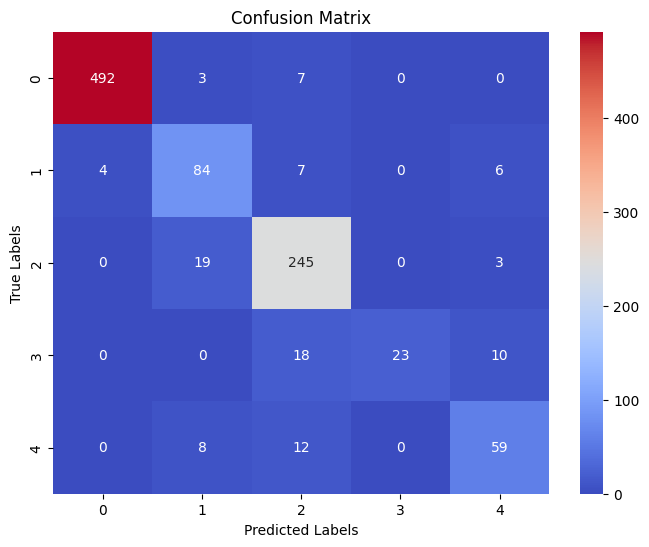

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="coolwarm", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [3]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np

IMAGE_SIZE = 128  
LEARNING_RATE = 1e-4  
EPOCHS = 50  

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

base_model.trainable = False

# Adding custom layers
x = base_model.output
x = Flatten()(x)  
x = Dense(128, activation='relu')(x)  
x = Dropout(0.4)(x) 
predictions = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

model.save('densenet121_real.keras')

# Predict on the validation set
val_generator.reset()  
predictions = model.predict(val_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_2              │ (None, 134, 134, 3)       │               0 │ input_layer_1[0][0]        │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 64, 64, 64)        │           9,408 │ zero_padding2d_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 64, 64, 64)        │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 64, 64, 64)        │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_3              │ (None, 66, 66, 64)        │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 32, 32, 64)        │               0 │ zero_padding2d_3[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 32, 32, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 32, 32, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 32, 32, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 32, 32, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 32, 32, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 32, 32, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 32, 32, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 9,135,429 (34.85 MB)

 Trainable params: 2,097,925 (8.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/50


C:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.6531 - loss: 1.2179 - val_accuracy: 0.7690 - val_loss: 0.6515
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.8593 - loss: 0.3971 - val_accuracy: 0.7870 - val_loss: 0.5614
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.8743 - loss: 0.3557 - val_accuracy: 0.8070 - val_loss: 0.5082
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.8834 - loss: 0.3294 - val_accuracy: 0.8220 - val_loss: 0.4931
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.8808 - loss: 0.3224 - val_accuracy: 0.8150 - val_loss: 0.4912
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.8943 - loss: 0.2842 - val_accuracy: 0.8300 - val_loss: 0.4898
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.8936 - loss: 0.2860 - val_accuracy: 0.8590 - val_loss: 0.4018
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.9011 - loss: 0.2729 - val_accuracy: 0.859

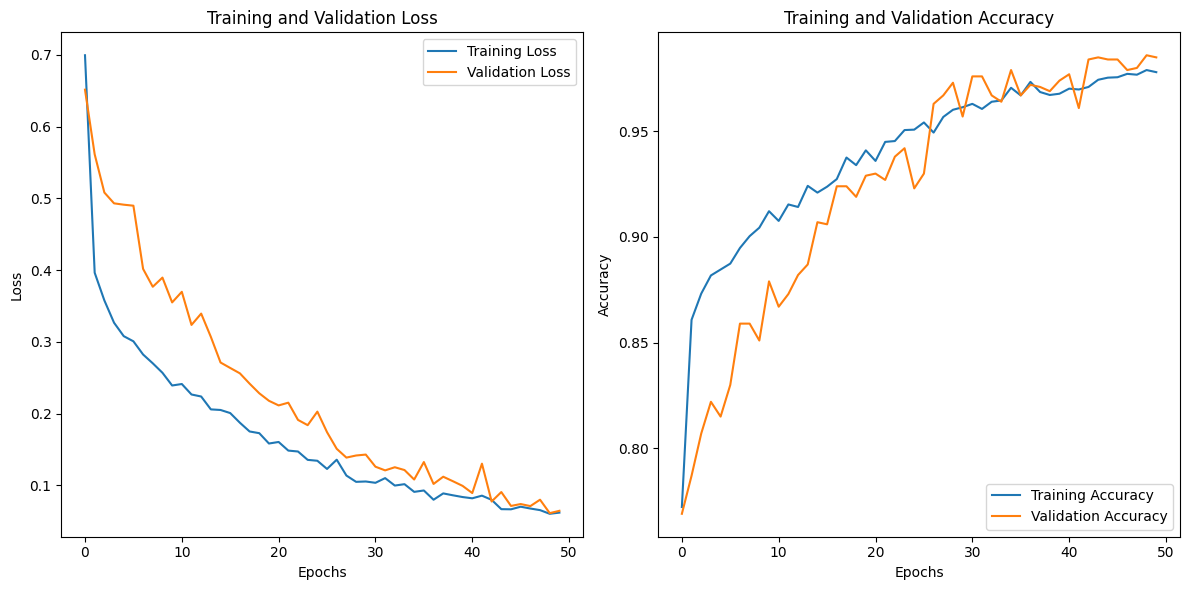

In [4]:
import matplotlib.pyplot as plt

# Extract metrics from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs_range = range(len(train_loss))

# Plot training and validation loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()


In [13]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
# report
class_labels = list(val_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

overall_accuracy = accuracy_score(y_true, y_pred)
overall_precision = precision_score(y_true, y_pred, average='weighted')
overall_recall = recall_score(y_true, y_pred, average='weighted')

print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Overall Precision: {overall_precision:.4f}")
print(f"Overall Recall: {overall_recall:.4f}")

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       502
           1       0.96      0.99      0.98       101
           2       0.98      1.00      0.99       267
           3       0.98      0.90      0.94        51
           4       0.97      0.96      0.97        79

    accuracy                           0.99      1000
   macro avg       0.98      0.97      0.97      1000
weighted avg       0.99      0.99      0.99      1000

Overall Accuracy: 0.9870
Overall Precision: 0.9871
Overall Recall: 0.9870


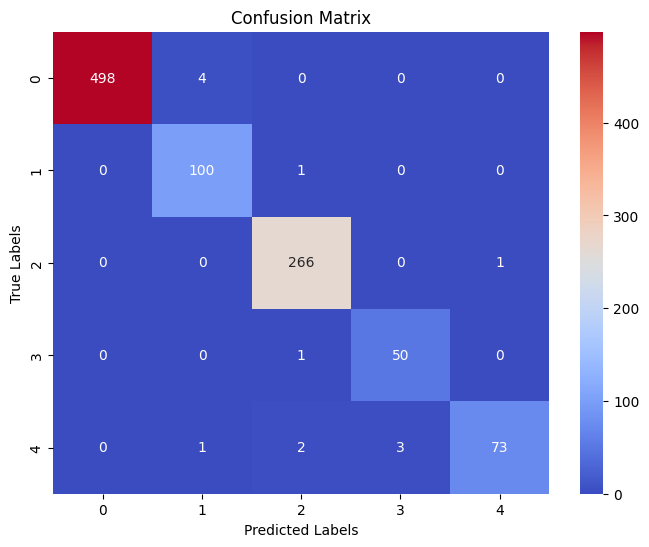

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="coolwarm", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [2]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np

# Define constants
IMAGE_SIZE = 128  
LEARNING_RATE = 1e-4  
EPOCHS = 50  

# Load the base model
base_model = Xception(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

# Freeze the base model layers
base_model.trainable = False

# Adding custom layers
x = base_model.output
x = Flatten()(x)  
x = Dense(128, activation='relu')(x)  
x = Dropout(0.4)(x)  
predictions = Dense(5, activation='softmax')(x)

# Define the full model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Model summary
model.summary()

# Train the model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

# Save the trained model
model.save('xception_real.keras')

# Predict on the validation set
val_generator.reset()  
predictions = model.predict(val_generator)

# Get predicted and true classes
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1 (Conv2D)         │ (None, 63, 63, 32)        │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1_bn               │ (None, 63, 63, 32)        │             128 │ block1_conv1[0][0]         │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1_act (Activation) │ (None, 63, 63, 32)        │               0 │ block1_conv1_bn[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2 (Conv2D)         │ (None, 61, 61, 64)        │          18,432 │ block1_conv1_act[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2_bn               │ (None, 61, 61, 64)        │             256 │ block1_conv2[0][0]         │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2_act (Activation) │ (None, 61, 61, 64)        │               0 │ block1_conv2_bn[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv1               │ (None, 61, 61, 128)       │           8,768 │ block1_conv2_act[0][0]     │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv1_bn            │ (None, 61, 61, 128)       │             512 │ block2_sepconv1[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2_act           │ (None, 61, 61, 128)       │               0 │ block2_sepconv1_bn[0][0]   │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2               │ (None, 61, 61, 128)       │          17,536 │ block2_sepconv2_act[0][0]  │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2_bn            │ (None, 61, 61, 128)       │             512 │ block2_sepconv2[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 31, 31, 128)       │           8,192 │ block1_conv2_act[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_pool (MaxPooling2D)    │ (None, 31, 31, 128)       │               

 Total params: 25,056,557 (95.58 MB)

 Trainable params: 4,195,077 (16.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

Epoch 1/50


C:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.7610 - loss: 0.6913 - val_accuracy: 0.7470 - val_loss: 0.6772
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.8579 - loss: 0.3947 - val_accuracy: 0.7870 - val_loss: 0.5954
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 151s 961ms/step - accuracy: 0.8653 - loss: 0.3615 - val_accuracy: 0.8160 - val_loss: 0.5311
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 151s 958ms/step - accuracy: 0.8878 - loss: 0.3186 - val_accuracy: 0.8290 - val_loss: 0.4737
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 148s 943ms/step - accuracy: 0.8955 - loss: 0.2878 - val_accuracy: 0.8250 - val_loss: 0.4747
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 150s 952ms/step - accuracy: 0.8948 - loss: 0.2897 - val_accuracy: 0.8550 - val_loss: 0.4225
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 151s 959ms/step - accuracy: 0.8902 - loss: 0.2912 - val_accuracy: 0.8600 - val_loss: 0.4165
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 150s 952ms/step - accuracy: 0.9123 - loss: 0.2510 - v

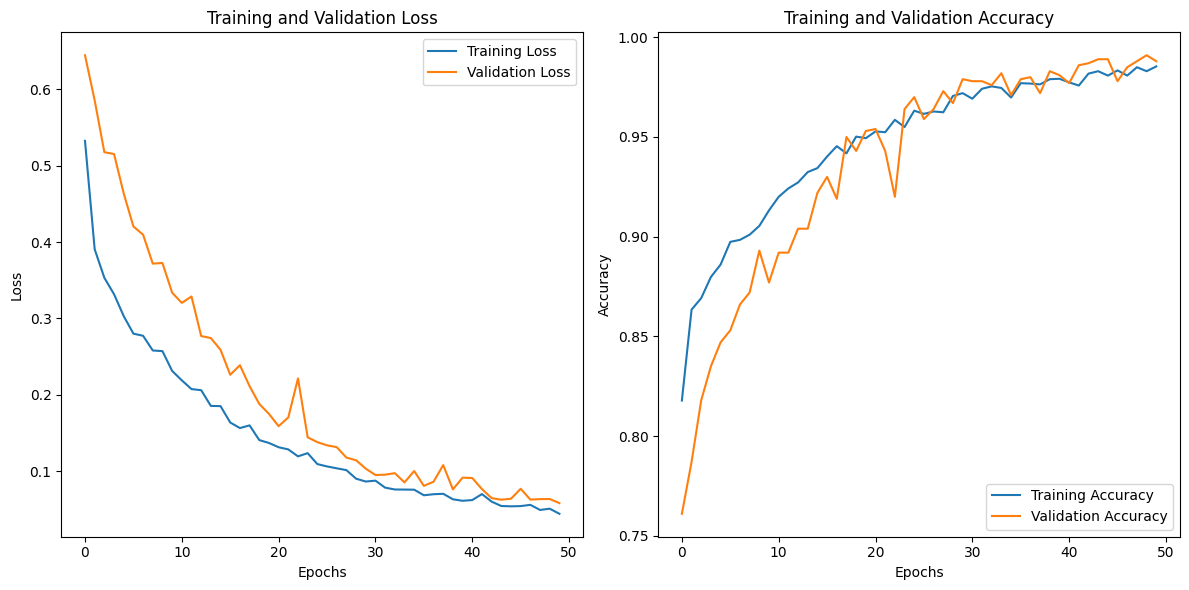

In [6]:
import matplotlib.pyplot as plt

# Extract metrics from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs_range = range(len(train_loss))

# Plot training and validation loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()


In [18]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
# report
class_labels = list(val_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

overall_accuracy = accuracy_score(y_true, y_pred)
overall_precision = precision_score(y_true, y_pred, average='weighted')
overall_recall = recall_score(y_true, y_pred, average='weighted')

print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Overall Precision: {overall_precision:.4f}")
print(f"Overall Recall: {overall_recall:.4f}")

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       502
           1       0.98      0.98      0.98       101
           2       0.99      0.99      0.99       267
           3       0.98      0.92      0.95        51
           4       0.95      0.99      0.97        79

    accuracy                           0.99      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.99      0.99      0.99      1000

Overall Accuracy: 0.9880
Overall Precision: 0.9881
Overall Recall: 0.9880


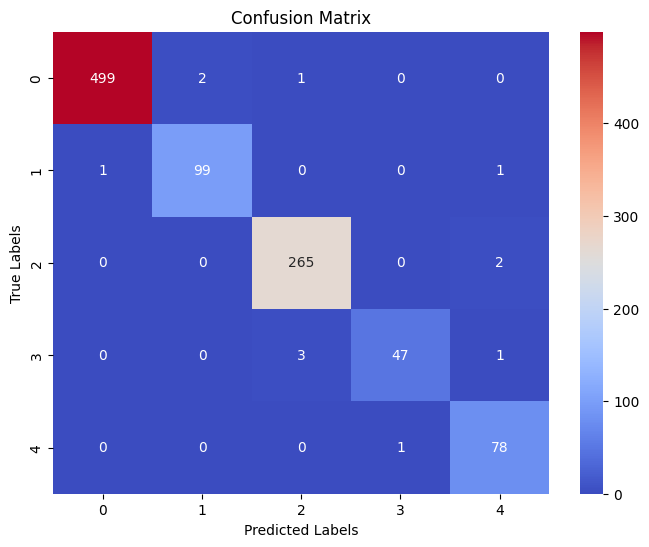

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="coolwarm", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 914ms/step
Predicted class: Moderate


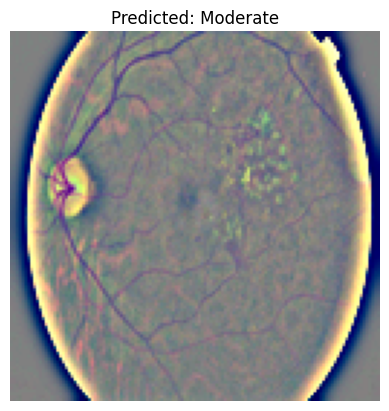

In [93]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Define class names corresponding to model outputs
class_names = ['No DR', 'Mild', 'Moderate', 'Proliferate DR', 'Severe']

# Load and preprocess the image
img_path = r'gauss_testing\moderate\1a7005be54cab1_2.png'  
img = load_img(img_path, target_size=(128, 128))  
img_array = img_to_array(img) 
img_array = np.expand_dims(img_array, axis=0) 
img_array = img_array / 255.0  

# Make the prediction
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions, axis=1)[0] 
predicted_class_name = class_names[predicted_class_index] 

# Print the prediction result
print(f"Predicted class: {predicted_class_name}")

# Display the image with the predicted class name
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {predicted_class_name}")
plt.show()
